In [22]:
import hashlib
import json
import os
from datetime import datetime
from pathlib import Path

import albumentations as A
import cv2
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import mlflow
import mlflow.pytorch
import numpy as np
import pandas as pd
import torch
import yaml
from dotenv import load_dotenv
from mlflow.data.dataset import Dataset as MLFLowDataset
from torch.utils.data import Dataset
from ultralytics import YOLO


In [23]:
load_dotenv()
np.random.seed(0)

In [24]:
# Model Configuration
TARGET_HEIGHT = 640  # YOLO works best with 640x640 (will be set automatically)
TARGET_WIDTH = 640  # YOLO typically uses square images

# Dataset Configuration
FINETUNE_DS_DIR = os.getenv("FINETUNE_DIR")
DATASET_IMAGES_DIR_NAME = "media"
DATASET_IMAGES_DIR = os.path.join(FINETUNE_DS_DIR, DATASET_IMAGES_DIR_NAME)
ANNOTATIONS_PATH = os.path.join(FINETUNE_DS_DIR, "picture_bb_annotations.csv")
IMG_METADATA_PATH = os.path.join(FINETUNE_DS_DIR, "media.csv")
DATASET_VERSION = "2025-30-09"

# Experiment logging
BEST_MODEL_PATH = os.getenv("BEST_MODEL_PATH")
MLFLOW_URI = os.getenv("MLFLOW_URI")
MLFLOW_EXPERIMENT_NAME = f"Fetal_Structures_yolo_{TARGET_HEIGHT}x{TARGET_WIDTH}_finetuned_solimed"
MLFLOW_USER = os.getenv("MLFLOW_USER")
MODEL_NAME = f"fetal_structures_yolo_{TARGET_HEIGHT}x{TARGET_WIDTH}_finetuned_solimed_{DATASET_VERSION}"

# Training parameters
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
K_FOLDS = 1
BATCH_SIZE = 32
NUM_EPOCHS = 2000
LEARNING_RATE = 1e-2
WEIGHT_DECAY = 5e-4
EARLY_STOPPING_PATIENCE = 200
N_VAL_VIDEOS = 8

In [25]:
# Show image metadata for frames
img_metadata_df = pd.read_csv(IMG_METADATA_PATH)
img_metadata_df = img_metadata_df[img_metadata_df['media_type'] == 'frame']

In [26]:
# Load and preprocess annotations
annotations_df = pd.read_csv(ANNOTATIONS_PATH)
annotations_df = annotations_df[annotations_df['bb_class'].isin(['NB', 'NT'])]
annotations_df = annotations_df[annotations_df['media_type'] == 'frame']
NUMBER_OF_CLASSES = len(pd.unique(annotations_df['bb_class']))

# Merge with media metadata to get file paths
annotations_df = annotations_df.merge(
    img_metadata_df[['id', 'file_path', 'filename']],
    left_on='media_id',
    right_on='id',
    suffixes=('', '_media')
)

# Convert x_min, y_min, width, height, to integers
annotations_df['x_min'] = annotations_df['x_min'].astype(int)
annotations_df['y_min'] = annotations_df['y_min'].astype(int)
annotations_df['width'] = annotations_df['width'].astype(int)
annotations_df['height'] = annotations_df['height'].astype(int)

In [27]:
unique_media_ids = annotations_df['media_id'].nunique()

In [28]:
# Pick some random media ids, select all their frames as the validation set
unique_media_ids = annotations_df['media_id'].unique()
val_media_ids = np.random.choice(unique_media_ids, size=N_VAL_VIDEOS, replace=False)
val_annotations_df = annotations_df[annotations_df['media_id'].isin(val_media_ids)]
train_annotations_df = annotations_df[~annotations_df['media_id'].isin(val_media_ids)]

# Check the split
val_size = len(val_annotations_df)
train_size = len(train_annotations_df)
total_size = len(annotations_df)
print(f"Total annotations: {len(annotations_df)}")
print(f"Training annotations: {len(train_annotations_df)}")
print(f"Validation annotations: {len(val_annotations_df)}")
print(f"Train/Val split: {train_size / total_size:.2f}/{val_size / total_size:.2f}")

# Create annotations dict in the format {filename: [(class_id, (xmin, ymin, xmax, ymax)), ...]}
ANNOTATIONS = {}
class_to_id = {'NB': 0, 'NT': 1}

for _, row in annotations_df.iterrows():
    fname = row['file_path']
    if fname not in ANNOTATIONS:
        ANNOTATIONS[fname] = []
    class_id = class_to_id[row['bb_class']]
    xmin = int(row['x_min'])
    ymin = int(row['y_min'])
    xmax = xmin + int(row['width'])
    ymax = ymin + int(row['height'])
    box = (xmin, ymin, xmax, ymax)
    ANNOTATIONS[fname].append((class_id, box))

# Create img_names lists
train_img_names = train_annotations_df['file_path'].unique().tolist()
val_img_names = val_annotations_df['file_path'].unique().tolist()

print(f"Total images with annotations: {len(ANNOTATIONS)}")
print(f"Training images: {len(train_img_names)}")
print(f"Validation images: {len(val_img_names)}")

Total annotations: 35
Training annotations: 24
Validation annotations: 11
Train/Val split: 0.69/0.31
Total images with annotations: 24
Training images: 16
Validation images: 8


In [29]:
print(val_media_ids)

['0d83b773-8eda-4cab-bb66-49b43b7dd1c3' 'ce2e9778-bc1e-41d3-a50f-ca956d8ba7e6' '2a654caf-749c-446b-b1a5-a1a7f217f5d5' '7e705d65-c0cb-4367-bcb3-df433a0b6218' 'f987f945-6fa6-4356-818c-b03ceb7e5657' '9296e799-922e-4a9c-b824-88c080dd249e' '29c410ab-81d4-46e3-b6ad-f9b2383e6e44' '5297ab8f-bb7e-4864-99e3-489ac873c89e']


In [30]:

# Aggressive data augmentation pipeline for training
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    # A.Affine(
    #     scale=(0.98, 1.02),
    #     translate_percent={"x": (-0.03, 0.03), "y": (-0.03, 0.03)},
    #     rotate=(-1, 1),
    #     shear=(-1, 1),
    #     p=0.5
    # ),
    #
    A.SmallestMaxSize(max_size=int(TARGET_HEIGHT * 1.01), p=1),
    A.RandomCrop(height=TARGET_HEIGHT, width=TARGET_WIDTH, p=1),
    A.Resize(height=TARGET_HEIGHT, width=TARGET_WIDTH, p=1),

    # A.ElasticTransform(alpha=20, sigma=5, p=0.2),
    # A.GridDistortion(num_steps=5, distort_limit=0.05, p=0.3),
    # A.OpticalDistortion(distort_limit=0.05, p=0.2),

    A.OneOf([
        A.MotionBlur(blur_limit=5, p=1.0),
        A.GaussianBlur(blur_limit=5, p=1.0),
    ], p=0.3),

    A.OneOf([
        A.GaussNoise(std_range=(0.05, 0.07), p=1.0),
        A.MultiplicativeNoise(multiplier=(0.98, 1.02), p=1.0),
    ], p=0.4),

    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.5),
    A.RandomGamma(gamma_limit=(90, 110), p=0.3),
], bbox_params={'format': 'pascal_voc', 'label_fields': ['class_labels']})

# Validation transform (minimal augmentation)
val_transform = A.Compose([
    A.Resize(height=TARGET_HEIGHT, width=TARGET_WIDTH),
], bbox_params={'format': 'pascal_voc', 'label_fields': ['class_labels']})

# Finetune

In [31]:
# Additional metrics functions (matching model-training.ipynb)
def box_iou(box1: torch.Tensor, box2: torch.Tensor) -> float:
    """
    Calculate IoU between two bounding boxes.
    Args:
        box1, box2: (cx, cy, w, h) in normalized [0, 1]
    Returns:
        IoU value
    """
    box1 = box1.clone()
    box2 = box2.clone()
    x1_min = float(box1[0] - box1[2] / 2)
    y1_min = float(box1[1] - box1[3] / 2)
    x1_max = float(box1[0] + box1[2] / 2)
    y1_max = float(box1[1] + box1[3] / 2)
    x2_min = float(box2[0] - box2[2] / 2)
    y2_min = float(box2[1] - box2[3] / 2)
    x2_max = float(box2[0] + box2[2] / 2)
    y2_max = float(box2[1] + box2[3] / 2)
    inter_xmin = max(x1_min, x2_min)
    inter_ymin = max(y1_min, y2_min)
    inter_xmax = min(x1_max, x2_max)
    inter_ymax = min(y1_max, y2_max)
    inter_area = max(0, inter_xmax - inter_xmin) * max(0, inter_ymax - inter_ymin)
    area1 = (x1_max - x1_min) * (y1_max - y1_min)
    area2 = (x2_max - x2_min) * (y2_max - y2_min)
    union = area1 + area2 - inter_area
    return inter_area / union if union > 0 else 0.0


In [32]:
# Setup MLflow
mlflow.set_tracking_uri(MLFLOW_URI)
mlflow.set_experiment(MLFLOW_EXPERIMENT_NAME)

print(f"MLflow Tracking URI: {MLFLOW_URI}")
print(f"MLflow Experiment: {MLFLOW_EXPERIMENT_NAME}")


MLflow Tracking URI: http://localhost:5000
MLflow Experiment: Fetal_Structures_yolo_640x640_finetuned_solimed


In [33]:
# Dataset and YOLO Dataset Preparation
class FinetuneDetectionDataset(Dataset):
    def __init__(self, image_root: str, img_names: list[str],
                 annotations: dict[str, list[tuple[int, tuple[int, int, int, int]]]],
                 transform: A.Compose | None = None):
        self.image_root = image_root
        self.img_names = img_names
        self.annotations = annotations
        self.transform = transform
        # Build class index from annotations present (assumes 0..N-1 are used)
        class_ids = set()
        for boxes in annotations.values():
            for cid, _ in boxes:
                class_ids.add(int(cid))
        self.class_to_idx = {('NB' if i == 0 else 'NT'): i for i in sorted(class_ids)}
        self.idx_to_class = {v: k for k, v in self.class_to_idx.items()}

    def __len__(self):
        return len(self.img_names)

    def _resolve_image_path(self, rel_path_no_ext: str) -> str:
        # Some file paths may already include an extension
        candidate = Path(self.image_root) / rel_path_no_ext
        if candidate.suffix:  # already has extension
            if candidate.exists():
                return str(candidate)
            # try relative variants
        # Try common extensions
        exts = ['.jpg', '.jpeg', '.png', '.bmp']
        for ext in exts:
            p = Path(self.image_root) / f"{rel_path_no_ext}{ext}"
            if p.exists():
                return str(p)
        # Also try if rel_path_no_ext already contains directories and a filename with no ext
        # Search for any file that starts with the given name in that directory
        p_no_ext = Path(self.image_root) / rel_path_no_ext
        if p_no_ext.parent.exists():
            stem = p_no_ext.name
            for file in p_no_ext.parent.iterdir():
                if file.is_file() and file.stem == stem:
                    return str(file)
        # Fallback to .jpg
        return str(Path(self.image_root) / f"{rel_path_no_ext}.jpg")

    def __getitem__(self, idx: int):
        img_key = self.img_names[idx]
        img_path = self._resolve_image_path(img_key)
        image = cv2.imread(img_path)
        if image is None:
            raise FileNotFoundError(f"Image not found: {img_path}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Collect bboxes and labels
        pairs = self.annotations.get(img_key, [])
        bboxes = []
        labels = []
        for cid, (xmin, ymin, xmax, ymax) in pairs:
            # Ensure valid box
            if xmax <= xmin or ymax <= ymin:
                continue
            bboxes.append([int(xmin), int(ymin), int(xmax), int(ymax)])
            labels.append(int(cid))

        # Albumentations expects class_labels alongside bbox_params
        class_labels = labels.copy()

        if self.transform is not None:
            transformed = self.transform(image=image, bboxes=bboxes, class_labels=class_labels)
            image = transformed['image']
            bboxes = transformed['bboxes']
            class_labels = transformed['class_labels']
            labels = class_labels

        # Ensure numpy arrays
        image = np.asarray(image)
        # img_name (without extension) for saving
        img_name = Path(img_key).name
        if '.' in img_name:
            img_name = img_name.rsplit('.', 1)[0]

        return {
            'image': image,
            'bboxes': bboxes,
            'labels': labels,
            'class_labels': class_labels,
            'img_name': img_name,
            'img_path': img_path,
        }


class YOLODatasetPreparator:
    """
    Prepares dataset for YOLO training by creating the proper directory structure
    and converting bounding boxes to YOLO format.
    """

    def __init__(self, dataset, output_dir):
        """
        Args:
            dataset: PyTorch Dataset instance (train_dataset or val_dataset)
            output_dir: Directory where YOLO format data will be saved
        """
        self.dataset = dataset
        self.output_dir = Path(output_dir)

    def prepare_split(self, split_name):
        """
        Prepare a data split (train/val) in YOLO format.

        Args:
            split_name: Name of the split ('train' or 'val')

        Returns:
            Path to the split directory
        """
        split_dir = self.output_dir / split_name
        images_dir = split_dir / 'images'
        labels_dir = split_dir / 'labels'

        # Create directories
        images_dir.mkdir(parents=True, exist_ok=True)
        labels_dir.mkdir(parents=True, exist_ok=True)

        print(f"Preparing {split_name} split with {len(self.dataset)} images...")

        for idx in range(len(self.dataset)):
            sample = self.dataset[idx]

            image = sample['image']
            bboxes = sample['bboxes']
            labels = sample['labels']
            img_name = sample['img_name']

            # Skip if no bounding boxes (after augmentation some might be filtered out)
            if len(bboxes) == 0:
                print(f"  Warning: Skipping image {img_name} (no bboxes after augmentation)")
                continue

            # Save image
            image_path = images_dir / f"{img_name}.jpg"
            import cv2
            cv2.imwrite(str(image_path), cv2.cvtColor(image, cv2.COLOR_RGB2BGR))

            # Convert bounding boxes to YOLO format and save labels
            label_path = labels_dir / f"{img_name}.txt"
            with open(label_path, 'w') as f:
                img_h, img_w = image.shape[:2]

                for bbox, label in zip(bboxes, labels):
                    x_min, y_min, x_max, y_max = bbox

                    # Convert to YOLO format (normalized center_x, center_y, width, height)
                    x_center = ((x_min + x_max) / 2) / img_w
                    y_center = ((y_min + y_max) / 2) / img_h
                    width = (x_max - x_min) / img_w
                    height = (y_max - y_min) / img_h

                    # Write: <class_id> <x_center> <y_center> <width> <height>
                    f.write(f"{int(label)} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}\n")

            if (idx + 1) % 50 == 0:
                print(f"  Processed {idx + 1}/{len(self.dataset)} images")

        print(f"✅ {split_name} split prepared: {len(list(images_dir.glob('*.jpg')))} images")
        return split_dir

In [34]:
# MLFlow dataset object for logging its metadata
class ImageListDataset(MLFLowDataset):
    def __init__(
            self,
            names: list[str],
            source: str = "picture_bb_annotations.csv",
            version: str = DATASET_VERSION
    ):
        self._names = names
        self._source = source
        self._version = version

    def to_dict(self):
        return {
            "name": "image_list_dataset",
            "digest": hashlib.md5(",".join(self._names).encode()).hexdigest(),
            "source_type": "inline",
            "source": self._source,
            "schema": None,
            "profile": json.dumps({
                "version": self._version,
                "num_images": len(self._names),
                "filenames": self._names
            }),
        }

In [35]:
def create_yolo_config(dataset_dir, train_dataset, output_path=None):
    """
    Create YOLO dataset configuration file.

    Args:
        dataset_dir: Root directory of the YOLO dataset
        train_dataset: Training dataset to extract class information
        output_path: Path to save the config file (optional)

    Returns:
        Path to the config file
    """
    if output_path is None:
        output_path = Path(dataset_dir) / 'dataset.yaml'

    config = {
        'path': str(Path(dataset_dir).absolute()),
        'train': 'train/images',
        'val': 'val/images',
        'nc': len(train_dataset.class_to_idx),
        'names': list(train_dataset.class_to_idx.keys())
    }

    with open(output_path, 'w') as f:
        yaml.dump(config, f, default_flow_style=False)

    print(f"✅ YOLO config created at: {output_path}")
    return output_path

In [36]:
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

# Instantiate datasets
train_dataset = FinetuneDetectionDataset(
    image_root=DATASET_IMAGES_DIR,
    img_names=train_img_names,
    annotations=ANNOTATIONS,
    transform=train_transform
)
val_dataset = FinetuneDetectionDataset(
    image_root=DATASET_IMAGES_DIR,
    img_names=val_img_names,
    annotations=ANNOTATIONS,
    transform=val_transform
)

# Prepare YOLO dataset directory under runs/finetune
FINETUNE_RUN_DIR = Path('runs') / 'finetune' / f'yolo_finetuned_{timestamp}'
YOLO_DATASET_DIR = FINETUNE_RUN_DIR / 'dataset'
YOLO_DATASET_DIR.mkdir(parents=True, exist_ok=True)

train_prep = YOLODatasetPreparator(train_dataset, YOLO_DATASET_DIR)
val_prep = YOLODatasetPreparator(val_dataset, YOLO_DATASET_DIR)
train_split_dir = train_prep.prepare_split('train')
val_split_dir = val_prep.prepare_split('val')

yolo_config_path = create_yolo_config(YOLO_DATASET_DIR, train_dataset, output_path=YOLO_DATASET_DIR / 'dataset.yaml')
print(f'YOLO dataset at: {YOLO_DATASET_DIR}')

Preparing train split with 16 images...
✅ train split prepared: 16 images
Preparing val split with 8 images...
✅ val split prepared: 8 images
✅ YOLO config created at: runs/finetune/yolo_finetuned_20251024_105917/dataset/dataset.yaml
YOLO dataset at: runs/finetune/yolo_finetuned_20251024_105917/dataset


In [37]:
# Visualize a sample with augmentation
def visualize_sample(sample, title="Sample"):
    """Visualize an image with its bounding boxes"""

    image = sample['image']
    bboxes = sample['bboxes']
    labels = sample['labels']

    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    ax.imshow(image)
    ax.set_title(title)

    # Draw bounding boxes
    colors = ['red', 'blue']
    label_names = {0: 'NB', 1: 'NT'}

    for bbox, label in zip(bboxes, labels):
        label = int(label)
        x_min, y_min, x_max, y_max = bbox
        width = x_max - x_min
        height = y_max - y_min
        rect = patches.Rectangle(
            (x_min, y_min), width, height,
            linewidth=2, edgecolor=colors[label % len(colors)],
            facecolor='none'
        )
        ax.add_patch(rect)

        # Add label text
        ax.text(
            x_min, y_min - 5,
            label_names[label],

            color=colors[label % len(colors)],
            fontsize=12,
            weight='bold',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=2)
        )

    ax.axis('off')
    plt.tight_layout()
    plt.show()

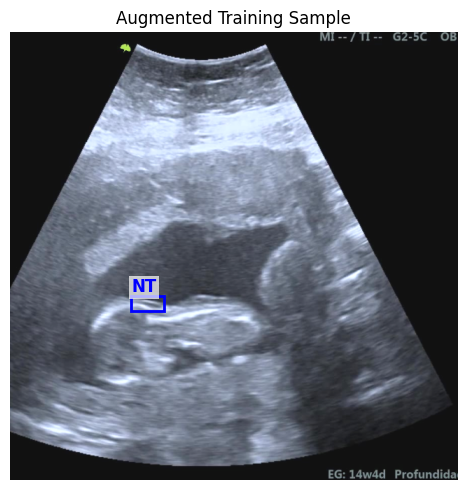

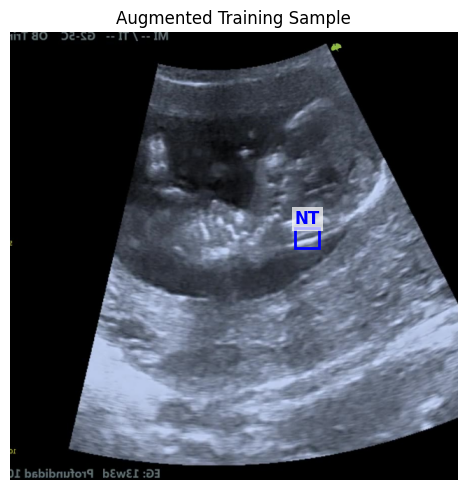

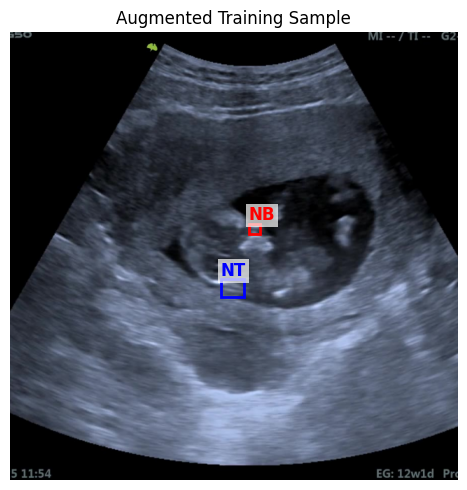

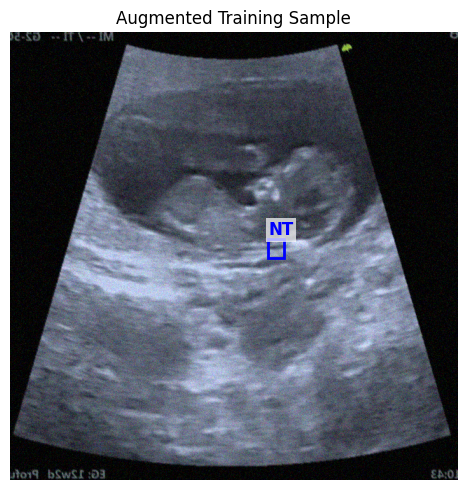

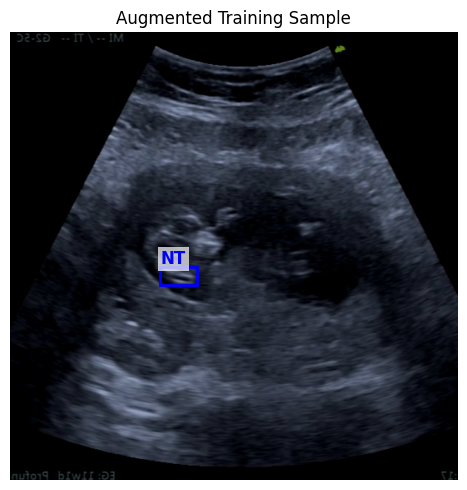

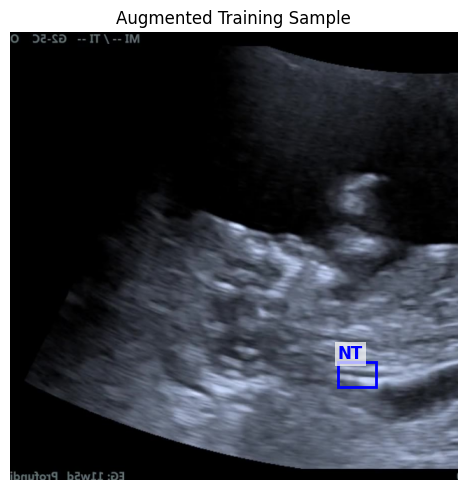

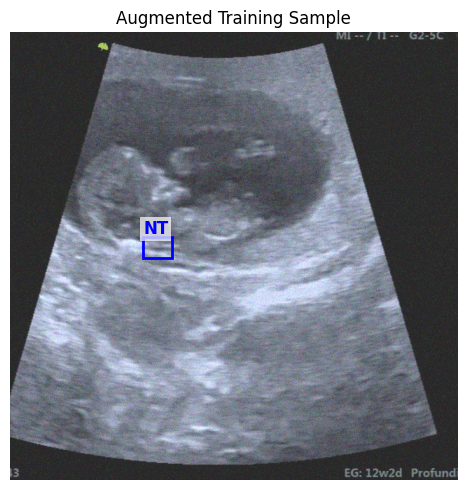

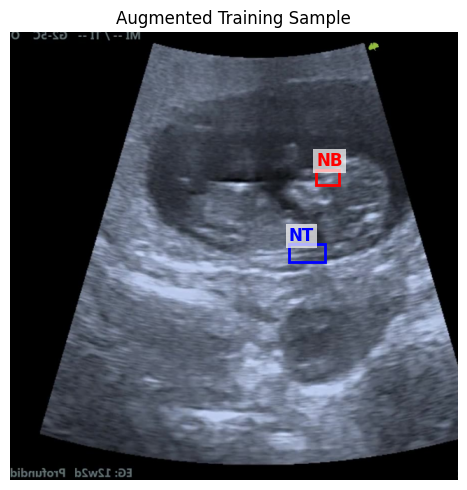

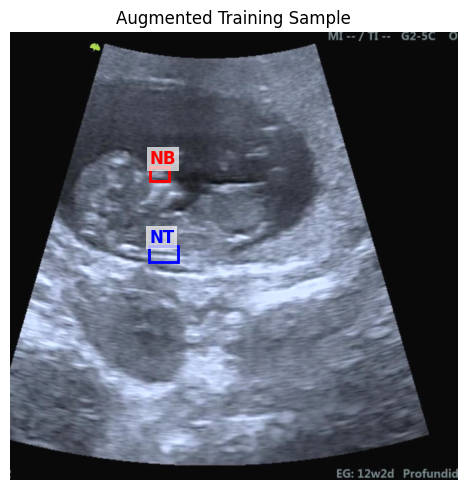

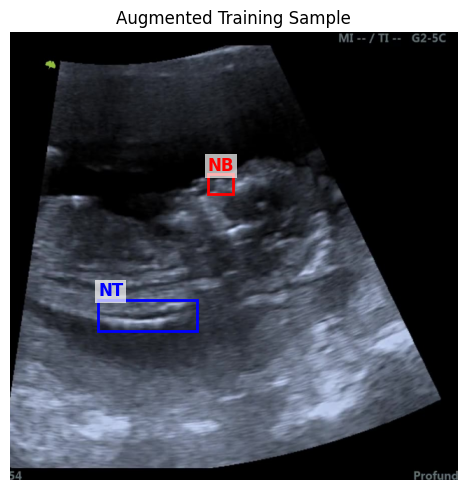

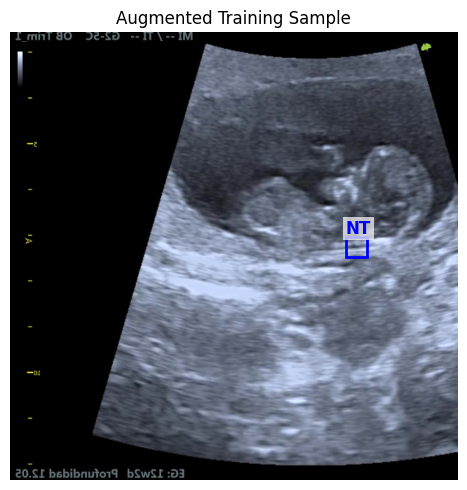

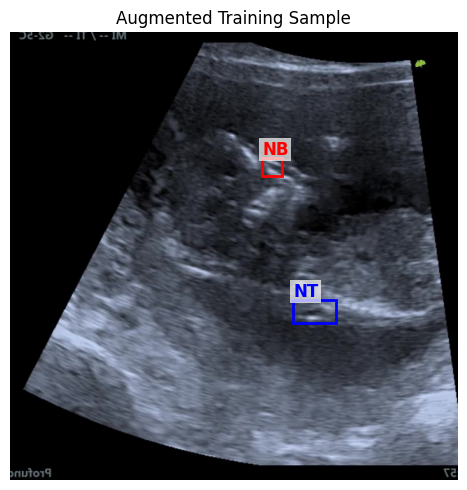

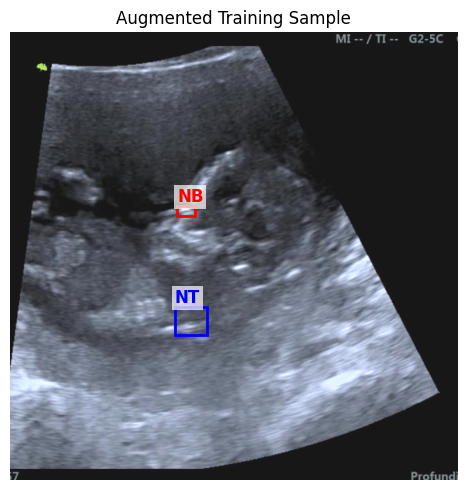

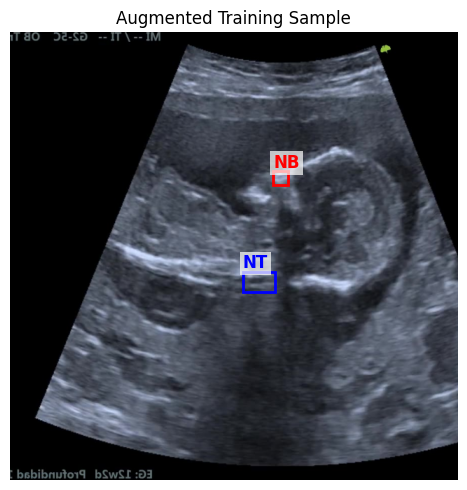

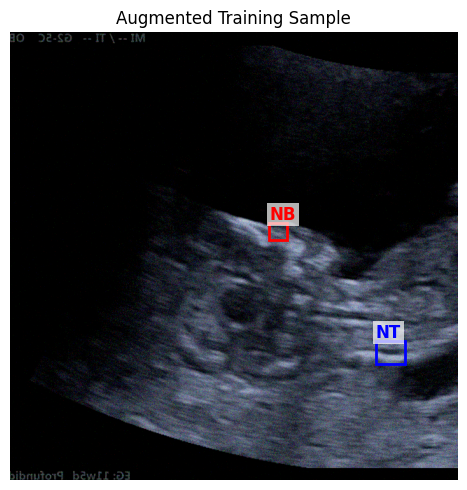

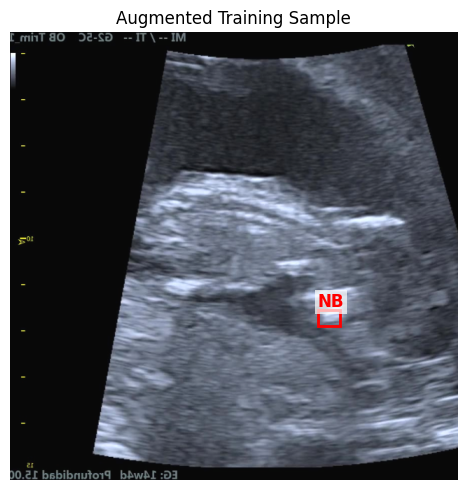

In [38]:
for i in range(len(train_dataset)):
    sample = train_dataset[i]
    visualize_sample(sample, "Augmented Training Sample")

In [39]:
# Finetune YOLO using prepared dataset and log to MLflow including Box IoU and mAP
model_ckpt = BEST_MODEL_PATH if BEST_MODEL_PATH and os.path.exists(BEST_MODEL_PATH) else 'yolov8n.pt'
print(f'Loading model checkpoint: {model_ckpt}')
model = YOLO(model_ckpt)

train_args = {
    'data': str(yolo_config_path),
    'epochs': NUM_EPOCHS,
    'imgsz': max(TARGET_HEIGHT, TARGET_WIDTH),
    'batch': BATCH_SIZE,
    'lr0': LEARNING_RATE,
    'weight_decay': WEIGHT_DECAY,
    'patience': EARLY_STOPPING_PATIENCE,
    'project': str(Path('runs') / 'finetune'),
    'name': f'yolo_finetuned_{timestamp}',
    'exist_ok': True,
    'optimizer': 'AdamW',
    'verbose': True,
    'device': DEVICE if DEVICE == 'cuda' else 'cpu',
    'workers': 0,
}

Loading model checkpoint: checkpoints/yolo_fetal_structures_20250923_223741/weights/best.pt


In [40]:
def mlflow_callback(trainer):
    epoch = trainer.epoch
    for k, v in trainer.metrics.items():
        if isinstance(v, (int, float)):
            safe_k = str(k).replace('(', '_').replace(')', '').replace('[', '_').replace(']', '').replace(' ', '_')
            mlflow.log_metric(safe_k, float(v), step=epoch)

In [41]:
mlflow_run_id = None
with mlflow.start_run(run_name=f"{MLFLOW_USER}_yolo_finetune_{timestamp}") as run:
    mlflow_run_id = run.info.run_id
    # Log parameters
    mlflow.log_params({
        'model_type': 'YOLOv8',
        'finetune_from': model_ckpt,
        'num_classes': len(train_dataset.class_to_idx),
        'class_names': list(train_dataset.class_to_idx.keys()),
        'train_images': len(train_dataset),
        'val_images': len(val_dataset),
        **train_args
    })
    # Log dataset inputs
    mlflow.log_input(ImageListDataset(train_img_names), context='train')
    mlflow.log_input(ImageListDataset(val_img_names), context='val')

    val_images_dir = YOLO_DATASET_DIR / 'val' / 'images'
    train_images_dir = YOLO_DATASET_DIR / 'train' / 'images'

    # Train
    input("Press Enter to start training...")
    model.add_callback("on_fit_epoch_end", mlflow_callback)
    results = model.train(**train_args)
    if hasattr(results, 'results_dict'):
        for k, v in results.results_dict.items():
            if isinstance(v, (int, float)):
                safe_k = str(k).replace('(', '_').replace(')', '').replace('[', '_').replace(']', '').replace(' ', '_')
                mlflow.log_metric(f"train/{safe_k}", float(v))

    # Locate best weights
    train_dir = Path(train_args['project']) / train_args['name']
    best_pt = train_dir / 'weights' / 'best.pt'
    if best_pt.exists():
        mlflow.log_artifact(str(best_pt))

    # Log per-epoch metrics from results.csv to MLflow with step
    results_csv = train_dir / 'results.csv'
    if results_csv.exists():
        try:
            df_results = pd.read_csv(results_csv)
            exclude_cols = {'epoch', 'time'}
            exclude_prefixes = ('lr/',)
            for _, row in df_results.iterrows():
                step = int(row['epoch']) if 'epoch' in row and not pd.isna(row['epoch']) else None
                for col in df_results.columns:
                    if col in exclude_cols or any(col.startswith(p) for p in exclude_prefixes):
                        continue
                    val = row[col]
                    if isinstance(val, (int, float, np.floating)) and np.isfinite(val):
                        safe_col = str(col).replace('(', '_').replace(')', '').replace('[', '_').replace(']', '').replace(
                            ' ', '_')
                        if step is not None:
                            mlflow.log_metric(f"train_epoch/{safe_col}", float(val), step=step)
                        else:
                            mlflow.log_metric(f"train_epoch/{safe_col}", float(val))
        except Exception as e:
            print(f"Warning: failed to log per-epoch metrics: {e}")

    # Validate on val split using Ultralytics metrics (includes mAP)
    val_results = model.val(data=str(yolo_config_path), split='val', verbose=True, plots=True)
    if hasattr(val_results, 'results_dict'):
        for k, v in val_results.results_dict.items():
            if isinstance(v, (int, float)):
                safe_k = str(k).replace('(', '_').replace(')', '').replace('[', '_').replace(']', '').replace(' ', '_')
                mlflow.log_metric(f"val/{safe_k}", float(v))

    # Custom evaluation: Box IoU using our helpers
    all_ious = []
    val_images_dir = YOLO_DATASET_DIR / 'val' / 'images'
    for img_file in list(val_images_dir.glob('*.jpg'))[:500]:  # cap for speed
        # Ground truth from label file
        label_file = (YOLO_DATASET_DIR / 'val' / 'labels' / (img_file.stem + '.txt'))
        gt_by_class = {}
        if label_file.exists():
            with open(label_file, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) == 5:
                        # robust parse: class id may be written as float like '1.0'
                        cid_token = parts[0]
                        try:
                            cid = int(cid_token)
                        except ValueError:
                            cid = int(float(cid_token))
                        cx, cy, w, h = map(float, parts[1:])
                        gt_by_class[cid] = torch.tensor([cx, cy, w, h], dtype=torch.float32)
        # Predictions
        preds = model.predict(str(img_file), conf=0.25, verbose=False)
        pred_by_class = {}
        if len(preds) > 0 and preds[0].boxes is not None:
            boxes = preds[0].boxes
            if hasattr(boxes, 'xywhn'):
                xywhn = boxes.xywhn.cpu().numpy()
            else:
                # fallback convert from xyxy to normalized
                img = cv2.imread(str(img_file))
                h, w = img.shape[:2]
                xyxy = boxes.xyxy.cpu().numpy()
                xywhn = []
                for x1, y1, x2, y2 in xyxy:
                    cx = ((x1 + x2) / 2) / w;
                    cy = ((y1 + y2) / 2) / h;
                    ww = (x2 - x1) / w;
                    hh = (y2 - y1) / h
                    xywhn.append([cx, cy, ww, hh])
                xywhn = np.array(xywhn)
            cls = boxes.cls.cpu().numpy().astype(int)
            conf = boxes.conf.cpu().numpy()
            # Keep highest conf per class
            for i, c in enumerate(cls):
                if c not in pred_by_class or conf[i] > pred_by_class[c][1]:
                    pred_by_class[c] = (torch.tensor(xywhn[i], dtype=torch.float32), float(conf[i]))
        # Compute metrics across classes present in either
        classes = set(list(gt_by_class.keys()) + list(pred_by_class.keys()))
        if not classes:
            continue
        gt_mask = torch.zeros(NUMBER_OF_CLASSES)
        pred_mask = torch.zeros(NUMBER_OF_CLASSES)
        gt_boxes = torch.zeros((NUMBER_OF_CLASSES, 4))
        pred_boxes = torch.zeros((NUMBER_OF_CLASSES, 4))
        for c in classes:
            if c in gt_by_class:
                gt_mask[c] = 1
                gt_boxes[c] = gt_by_class[c]
            if c in pred_by_class:
                pred_mask[c] = 1
                pred_boxes[c] = pred_by_class[c][0]
        # Per-image custom metrics
        # Average IoU over classes present in both
        ious = []
        for c in classes:
            if gt_mask[c] == 1 and pred_mask[c] == 1:
                ious.append(box_iou(gt_boxes[c], pred_boxes[c]))
        if ious:
            all_ious.append(float(np.mean(ious)))

    if all_ious:
        mlflow.log_metric('val_box_iou_mean', float(np.mean(all_ious)))

print('Finetuning complete.')

New https://pypi.org/project/ultralytics/8.3.221 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.203 🚀 Python-3.12.11 torch-2.4.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060, 11918MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=runs/finetune/yolo_finetuned_20251024_105917/dataset/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=2000, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=checkpoints/yolo_fetal_structures_20250923_223741/